In [2]:
import numpy as np
import matplotlib.pyplot as plt

# function
def f(x):
    return x * np.sin(4*x)

# derivative: f'(x) = sin(4x) + 4x cos(4x)
def g(x):
    return np.sin(4*x) + 4*x*np.cos(4*x)

# Newton method
def newton_method(f, g, x0, tol=1e-8, max_iter=100):
    x = x0

    for i in range(max_iter):
        if abs(g(x)) < 1e-12:
            print("Derivative too close to zero.")
            break

        x_new = x - f(x)/g(x)

        if abs(x_new - x) < tol:
            return x_new, i + 1

        x = x_new

    return x, max_iter

In [3]:
x0 = 0.5

x1, iterations = newton_method(f, g, x0)

print("Starting guess:", x0)
print("Root found:", x1)
print("Number of iterations:", iterations)

Starting guess: 0.5
Root found: -5.497787143782138
Number of iterations: 5


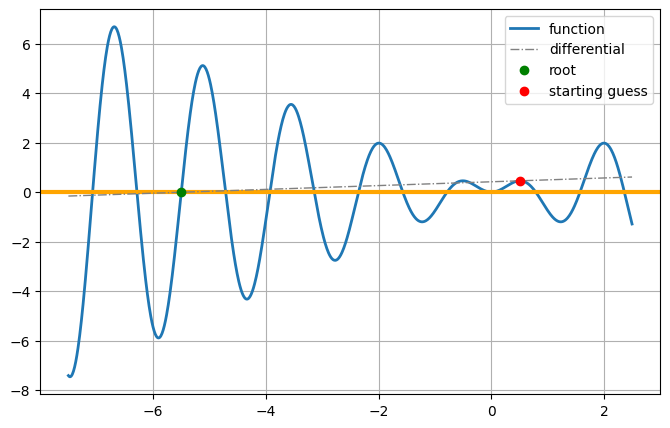

In [4]:
t = np.arange(min(x1, x0)-2, max(x1, x0)+2, 0.01)

plt.figure(figsize=(8,5))

plt.plot(t, f(t), lw=2, label='function')
plt.axhline(0, color='orange', lw=3)

# tangent line at x0
plt.plot(t, g(x0)*t - g(x0)*x0 + f(x0), '-.', color='grey', label='differential', lw=1)

# points
plt.plot(x1, f(x1), 'go', label='root')
plt.plot(x0, f(x0), 'ro', label='starting guess')

plt.legend()
plt.grid(True)
plt.show()

In [6]:
starting_points = np.linspace(-2, 6, 400)

roots = []
iteration_counts = []

for x0 in starting_points:
    root, iters = newton_method(f, g, x0)
    roots.append(root)
    iteration_counts.append(iters)

roots = np.array(roots)
iteration_counts = np.array(iteration_counts)

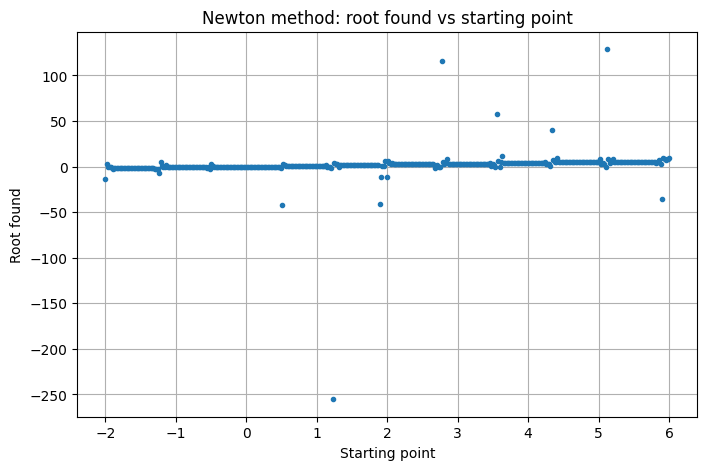

In [7]:
plt.figure(figsize=(8,5))
plt.plot(starting_points, roots, '.')
plt.xlabel("Starting point")
plt.ylabel("Root found")
plt.title("Newton method: root found vs starting point")
plt.grid(True)
plt.show()

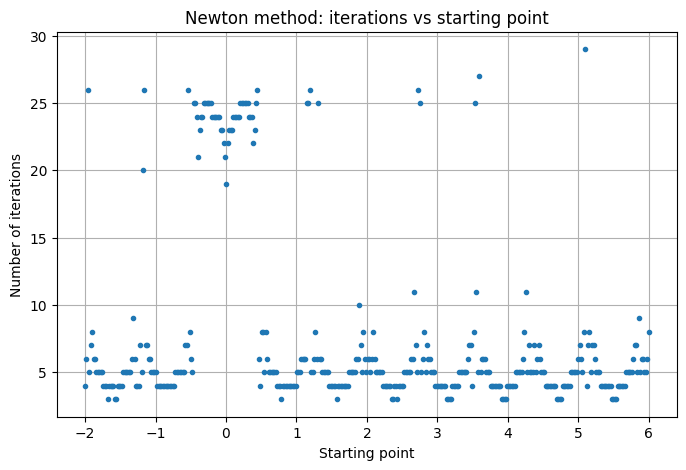

In [8]:
plt.figure(figsize=(8,5))
plt.plot(starting_points, iteration_counts, '.')
plt.xlabel("Starting point")
plt.ylabel("Number of iterations")
plt.title("Newton method: iterations vs starting point")
plt.grid(True)
plt.show()